In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up for better plots/
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Data Processing

## Dataset 1: India Data Portal - Employment Generated

In [66]:
EmpGen = pd.read_csv('/Users/vidhi/college baby/sem 6/Topics in EconRes/FinalPaperMaterial/2. Data/1. Raw/India Data Portal (PC lvl)/Employment Generated.csv')
EmpGen.head()

,_id,id,year,state_name,district_name,block_name,gp_name,reg_hh,reg_pers,del_jobcards_hh,...,emp_offer_hh,emp_offer_pers,emp_avail_hh,emp_avail_pers,emp_avail_tot_persondays,emp_avail_central_persondays,emp_avail_states_persondays,fam_completed_100_days,land_reform_benef_hh,disabled_benef_indiv
0,1,0,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Campbell Bay,376.0,800.0,0.0,...,29.0,35.0,16.0,20.0,381.0,381.0,0.0,0.0,2.0,0.0
1,2,1,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Govindnagar,429.0,813.0,0.0,...,88.0,94.0,62.0,66.0,745.0,745.0,0.0,0.0,0.0,0.0
2,3,2,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Great & Little Nicobar,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,3,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Laxmi Nagar,460.0,819.0,0.0,...,30.0,30.0,29.0,29.0,214.0,214.0,0.0,0.0,0.0,0.0
4,5,4,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Chowra Tc,309.0,632.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 1.1 Checking what information is stored in the dataset

In [69]:
EmpGen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2642550 entries, 0 to 2642549
Data columns (total 29 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   _id                           int64  
 1   id                            int64  
 2   year                          object 
 3   state_name                    object 
 4   district_name                 object 
 5   block_name                    object 
 6   gp_name                       object 
 7   reg_hh                        float64
 8   reg_pers                      float64
 9   del_jobcards_hh               float64
 10  del_jobcards_pers             float64
 11  incl_jobcards_hh              float64
 12  incl_jobcards_pers            float64
 13  cumul_hh_jobcards_sc          float64
 14  cumul_hh_jobcards_sts         float64
 15  cumul_hh_jobcards_others      float64
 16  cumul_hh_jobcards_tot         float64
 17  emp_demand_hh                 float64
 18  emp_demand_pers       

### 1.2 Confirming the key of the dataset

In [80]:
EmpGen[['year','state_name','district_name','block_name','gp_name']].value_counts().unique()

array([2, 1])

Seems like there are some 'keys' that actually appear twice instead of once. Let's select the entries for these keys and store them in a new dataset.

In [95]:
EmpGen_dup = EmpGen[EmpGen.duplicated(
    subset=['year','state_name','district_name','block_name','gp_name'],
    keep=False
)]

### 1.3 Dealing with duplicates

Since we only care about specific columns, let's see how the duplicates behave for those specific columns.

In [93]:
cols = ['id',
    'year','state_name','district_name','block_name','gp_name',
    'reg_hh', 'reg_pers',
    'cumul_hh_jobcards_sc',
    'cumul_hh_jobcards_sts',
    'cumul_hh_jobcards_others',
    'cumul_hh_jobcards_tot']

reg_hh - number of registered households <br>
reg_pers - number of registered persons <br>

cumul_hh_jobcards_sc - Cummulative job cards issued for sc households <br>
cumul_hh_jobcards_sts - Cummulative job cards issued for st households <br>
cumul_hh_jobcards_others - Cummulative job cards issued for other households <br>
cumul_hh_jobcards_tot - Cummulative job cards issued for all households

In [94]:
EmpGen_dup[['reg_hh', 'reg_pers', 'cumul_hh_jobcards_sc',
     'cumul_hh_jobcards_sts',
     'cumul_hh_jobcards_others',
     'cumul_hh_jobcards_tot']].head(10)

,reg_hh,reg_pers,cumul_hh_jobcards_sc,cumul_hh_jobcards_sts,cumul_hh_jobcards_others,cumul_hh_jobcards_tot
2607,1235.0,2652.0,380.0,58.0,797.0,1235.0
2608,590.0,1072.0,20.0,5.0,565.0,590.0
14777,85.0,173.0,0.0,85.0,0.0,85.0
14790,0.0,0.0,0.0,0.0,0.0,0.0
16512,14760.0,29180.0,591.0,12967.0,1189.0,14747.0
16513,6.0,8.0,0.0,0.0,0.0,0.0
40595,210.0,545.0,3.0,196.0,11.0,210.0
40596,584.0,1380.0,0.0,518.0,61.0,579.0
40626,0.0,0.0,0.0,0.0,0.0,0.0
40627,424.0,1053.0,1.0,417.0,6.0,424.0


Let's check what these duplicates really look like for some randomly selected GPs.

In [97]:
EmpGen_dup

,_id,id,year,state_name,district_name,block_name,gp_name,reg_hh,reg_pers,del_jobcards_hh,...,emp_offer_hh,emp_offer_pers,emp_avail_hh,emp_avail_pers,emp_avail_tot_persondays,emp_avail_central_persondays,emp_avail_states_persondays,fam_completed_100_days,land_reform_benef_hh,disabled_benef_indiv
2607,2608,2607,2014-2015,Andhra Pradesh,Cuddapah,Chitvel,Chitvel,1235.0,2652.0,0.0,...,253.0,358.0,223.0,294.0,7443.0,7443.0,0.0,11.0,36.0,1.0
2608,2609,2608,2014-2015,Andhra Pradesh,Cuddapah,Chitvel,Chitvel,590.0,1072.0,0.0,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14777,14778,14777,2014-2015,Arunachal Pradesh,West Kameng,Nafra,Mathow,85.0,173.0,0.0,...,76.0,77.0,76.0,77.0,1737.0,1737.0,0.0,0.0,0.0,0.0
14790,14791,14790,2014-2015,Arunachal Pradesh,West Kameng,Nafra,Mathow,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16512,16513,16512,2014-2015,Assam,Karbi Anglong,Samelangso,No Panchayat,14760.0,29180.0,26.0,...,9593.0,9690.0,9362.0,9395.0,52153.0,52153.0,0.0,0.0,184.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2638204,2638205,2638204,2023-2024,Uttarakhand,Tehri Garhwal,Pratapnagar,Oanalgaon,140.0,158.0,1.0,...,109.0,109.0,109.0,109.0,1952.0,1952.0,0.0,0.0,0.0,0.0
2638212,2638213,2638212,2023-2024,Uttarakhand,Tehri Garhwal,Pratapnagar,Pokhri,178.0,194.0,0.0,...,37.0,37.0,29.0,29.0,406.0,406.0,0.0,0.0,0.0,0.0
2638213,2638214,2638213,2023-2024,Uttarakhand,Tehri Garhwal,Pratapnagar,Pokhri,243.0,412.0,0.0,...,202.0,297.0,104.0,151.0,2206.0,2206.0,0.0,0.0,0.0,0.0
2638215,2638216,2638215,2023-2024,Uttarakhand,Tehri Garhwal,Pratapnagar,Pujargaon,170.0,230.0,0.0,...,50.0,55.0,49.0,54.0,735.0,735.0,0.0,0.0,0.0,0.0


In [86]:
display(EmpGen[(EmpGen['district_name'] == 'Cuddapah') & (EmpGen['gp_name'] == 'Chitvel')])
display(EmpGen[(EmpGen['district_name'] == 'West Kameng') & (EmpGen['gp_name'] == 'Mathow')].head(8))
display(EmpGen[(EmpGen['district_name'] == 'Tehri Garhwal') & (EmpGen['gp_name'] == 'Oanalgaon')].head(8))

,_id,id,year,state_name,district_name,block_name,gp_name,reg_hh,reg_pers,del_jobcards_hh,...,emp_offer_hh,emp_offer_pers,emp_avail_hh,emp_avail_pers,emp_avail_tot_persondays,emp_avail_central_persondays,emp_avail_states_persondays,fam_completed_100_days,land_reform_benef_hh,disabled_benef_indiv
2607,2608,2607,2014-2015,Andhra Pradesh,Cuddapah,Chitvel,Chitvel,1235.0,2652.0,0.0,...,253.0,358.0,223.0,294.0,7443.0,7443.0,0.0,11.0,36.0,1.0
2608,2609,2608,2014-2015,Andhra Pradesh,Cuddapah,Chitvel,Chitvel,590.0,1072.0,0.0,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
258741,258742,258741,2015-2016,Andhra Pradesh,Cuddapah,Chitvel,Chitvel,655.0,1606.0,590.0,...,124.0,187.0,121.0,166.0,5821.0,5821.0,0.0,19.0,26.0,0.0
258742,258743,258742,2015-2016,Andhra Pradesh,Cuddapah,Chitvel,Chitvel,615.0,1106.0,1.0,...,117.0,145.0,103.0,119.0,3810.0,3810.0,0.0,1.0,16.0,0.0


,_id,id,year,state_name,district_name,block_name,gp_name,reg_hh,reg_pers,del_jobcards_hh,...,emp_offer_hh,emp_offer_pers,emp_avail_hh,emp_avail_pers,emp_avail_tot_persondays,emp_avail_central_persondays,emp_avail_states_persondays,fam_completed_100_days,land_reform_benef_hh,disabled_benef_indiv
14777,14778,14777,2014-2015,Arunachal Pradesh,West Kameng,Nafra,Mathow,85.0,173.0,0.0,...,76.0,77.0,76.0,77.0,1737.0,1737.0,0.0,0.0,0.0,0.0
14790,14791,14790,2014-2015,Arunachal Pradesh,West Kameng,Nafra,Mathow,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
270911,270912,270911,2015-2016,Arunachal Pradesh,West Kameng,Nafra,Mathow,85.0,173.0,0.0,...,57.0,58.0,55.0,55.0,696.0,696.0,0.0,0.0,0.0,0.0
270924,270925,270924,2015-2016,Arunachal Pradesh,West Kameng,Nafra,Mathow,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
529086,529087,529086,2016-2017,Arunachal Pradesh,West Kameng,Nafra,Mathow,83.0,166.0,2.0,...,82.0,91.0,82.0,91.0,2272.0,2272.0,0.0,0.0,0.0,0.0
529098,529099,529098,2016-2017,Arunachal Pradesh,West Kameng,Nafra,Mathow,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
787770,787771,787770,2017-2018,Arunachal Pradesh,West Kameng,Nafra,Mathow,74.0,138.0,9.0,...,76.0,76.0,74.0,74.0,1098.0,1098.0,0.0,0.0,0.0,0.0
787782,787783,787782,2017-2018,Arunachal Pradesh,West Kameng,Nafra,Mathow,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,_id,id,year,state_name,district_name,block_name,gp_name,reg_hh,reg_pers,del_jobcards_hh,...,emp_offer_hh,emp_offer_pers,emp_avail_hh,emp_avail_pers,emp_avail_tot_persondays,emp_avail_central_persondays,emp_avail_states_persondays,fam_completed_100_days,land_reform_benef_hh,disabled_benef_indiv
251766,251767,251766,2014-2015,Uttarakhand,Tehri Garhwal,Pratapnagar,Oanalgaon,127.0,220.0,0.0,...,103.0,104.0,102.0,103.0,2129.0,2129.0,0.0,0.0,0.0,0.0
251767,251768,251767,2014-2015,Uttarakhand,Tehri Garhwal,Pratapnagar,Oanalgaon,156.0,286.0,0.0,...,116.0,121.0,109.0,114.0,5479.0,5479.0,0.0,0.0,0.0,0.0
509114,509115,509114,2015-2016,Uttarakhand,Tehri Garhwal,Pratapnagar,Oanalgaon,202.0,295.0,0.0,...,198.0,211.0,168.0,178.0,5117.0,5117.0,0.0,1.0,0.0,0.0
509115,509116,509115,2015-2016,Uttarakhand,Tehri Garhwal,Pratapnagar,Oanalgaon,160.0,290.0,0.0,...,112.0,113.0,111.0,112.0,5116.0,5116.0,0.0,0.0,0.0,0.0
767953,767954,767953,2016-2017,Uttarakhand,Tehri Garhwal,Pratapnagar,Oanalgaon,186.0,271.0,16.0,...,176.0,183.0,170.0,177.0,8808.0,8808.0,0.0,0.0,0.0,0.0
767954,767955,767954,2016-2017,Uttarakhand,Tehri Garhwal,Pratapnagar,Oanalgaon,123.0,220.0,40.0,...,122.0,126.0,122.0,126.0,7267.0,7267.0,0.0,0.0,0.0,0.0
1026098,1026099,1026098,2017-2018,Uttarakhand,Tehri Garhwal,Pratapnagar,Oanalgaon,180.0,205.0,14.0,...,166.0,171.0,158.0,161.0,8654.0,8654.0,0.0,0.0,0.0,0.0
1026099,1026100,1026099,2017-2018,Uttarakhand,Tehri Garhwal,Pratapnagar,Oanalgaon,124.0,136.0,1.0,...,121.0,123.0,116.0,118.0,9397.0,9397.0,0.0,0.0,0.0,0.0


These results tell us that there are three types of cases.

Case 1 (Mathow): Real rows accompanied by garbage 'zero' rows

Case 2 (Chitvel): Data Spliting - Two rows with different non-zero values. One looks “complete”, one looks partial, hinting at split reporting

Case 3 (Oanalgaon): Conflicting full values - Both rows have non-zero, substantial values, resulting in true duplication ambiguity

We can remove the zero rows first

In [98]:
EmpGen_clean = EmpGen.copy()
num_cols = ['reg_hh', 'reg_pers',
    'cumul_hh_jobcards_sc',
    'cumul_hh_jobcards_sts',
    'cumul_hh_jobcards_others',
    'cumul_hh_jobcards_tot']
EmpGen_clean = EmpGen_clean[EmpGen_clean[num_cols].sum(axis=1) > 0]

For the rest, we can use the max() function to keep the max of the two values.

Duplicate entries likely arise from administrative reporting inconsistencies. Since variables are cumulative counts, the maximum value across duplicates best approximates the final recorded total while avoiding double counting.

In [99]:
EmpGen_clean = EmpGen_clean.groupby(
    ['year','state_name','district_name','block_name','gp_name'],
    as_index=False
)[num_cols].max()

In [101]:
EmpGen_clean[['year','state_name','district_name','block_name','gp_name']].value_counts().unique()

array([1])

Now all the keys are unique!

### 1.4 Selecting necessarily columns

In [103]:
JobCards = EmpGen[['year','state_name', 'district_name', 'block_name', 'gp_name', 'reg_hh', 'reg_pers', 'cumul_hh_jobcards_sc', 
                   'cumul_hh_jobcards_sts', 'cumul_hh_jobcards_others', 'cumul_hh_jobcards_tot']]
JobCards.head()

,year,state_name,district_name,block_name,gp_name,reg_hh,reg_pers,cumul_hh_jobcards_sc,cumul_hh_jobcards_sts,cumul_hh_jobcards_others,cumul_hh_jobcards_tot
0,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Campbell Bay,376.0,800.0,4.0,2.0,369.0,375.0
1,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Govindnagar,429.0,813.0,0.0,0.0,429.0,429.0
2,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Great & Little Nicobar,0.0,0.0,0.0,0.0,0.0,0.0
3,2014-2015,Andaman And Nicobar,Nicobars,Campbell Bay,Laxmi Nagar,460.0,819.0,0.0,0.0,460.0,460.0
4,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Chowra Tc,309.0,632.0,0.0,309.0,0.0,309.0


### Dataset 2: India Data Portal - Workers

In [16]:
Workers = pd.read_csv('/Users/vidhi/college baby/sem 6/Topics in EconRes/FinalPaperMaterial/2. Data/1. Raw/India Data Portal/Category Wise Workers.csv')
Workers.head()

#registered_workers_scs - Number of registered workers from SCs
#registered_workers_sts - Number of registered workers from STs
#registered_workers_others - Number of registered workers from other categories
#total_registered_workers - Total number of registered workers

#active_workers_scs - Number of active workers from SCs
#active_workers_sts - Number of active workers from STs
#active_workers_others - Number of active workers from other categories
#total_active_workers - Total number of active workers

,_id,id,year,state_name,district_name,block_name,gp_name,applied_jobcards,issued_jobcards,registered_workers_scs,registered_workers_sts,registered_workers_others,total_registered_workers,registered_workers_women,active_jobcards,active_workers_scs,active_workers_sts,active_workers_others,total_active_workers,active_workers_women
0,1,0.0,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Chowra Tc,309.0,309.0,0.0,646.0,2.0,648.0,317.0,150.0,0.0,63.0,2.0,65.0,24.0
1,2,1.0,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Kamorta Tc,612.0,612.0,0.0,1255.0,191.0,1446.0,740.0,388.0,0.0,443.0,15.0,458.0,218.0
2,3,2.0,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Katchal Tc,452.0,452.0,0.0,435.0,307.0,742.0,299.0,273.0,0.0,200.0,89.0,289.0,114.0
3,4,3.0,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Nancowry Tc,236.0,236.0,0.0,590.0,1.0,591.0,279.0,177.0,0.0,177.0,1.0,178.0,90.0
4,5,4.0,2014-2015,Andaman And Nicobar,Nicobars,Nancowry,Teressa Tc,332.0,332.0,0.0,580.0,1.0,581.0,237.0,257.0,0.0,78.0,1.0,79.0,21.0


In [17]:
display(Workers['year'].unique())
Workers['state_name'].unique()

array(['2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019',
       '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024'],
      dtype=object)

array(['Andaman And Nicobar', 'Andhra Pradesh', 'Arunachal Pradesh',
       'Assam', 'Bihar', 'Chhattisgarh', 'Dn Haveli And Dd', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan',
       'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal'], dtype=object)

In [19]:
Workers_2014 = Workers[Workers['year'] == '2014-2015']
Workers_2014.describe()

,_id,id,applied_jobcards,issued_jobcards,registered_workers_scs,registered_workers_sts,registered_workers_others,total_registered_workers,registered_workers_women,active_jobcards,active_workers_scs,active_workers_sts,active_workers_others,total_active_workers,active_workers_women
count,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000,264986.000000
mean,132493.500000,132493.505412,488.404818,483.634049,193.532258,150.630720,679.296653,1023.459632,485.597250,243.036651,106.921237,87.391489,346.382598,540.695324,274.646170
std,76495.013553,76495.845879,645.955388,640.690912,388.451200,460.458284,1055.442052,1408.348572,694.605399,390.097614,234.775403,271.379348,565.581791,786.485338,417.360254
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,66247.250000,66246.250000,148.000000,146.000000,14.000000,0.000000,121.000000,275.000000,103.000000,47.000000,3.000000,0.000000,41.000000,110.000000,40.000000
50%,132493.500000,132493.500000,299.000000,295.000000,86.000000,2.000000,359.000000,606.000000,269.000000,137.000000,41.000000,0.000000,172.000000,305.000000,131.000000
75%,198739.750000,198740.750000,576.000000,571.000000,227.000000,77.000000,776.000000,1182.000000,579.000000,295.000000,125.000000,33.000000,409.000000,669.000000,351.000000
max,264986.000000,264987.000000,37660.000000,36430.000000,12340.000000,44535.000000,24593.000000,64070.000000,31173.000000,13851.000000,8154.000000,27841.000000,16559.000000,36024.000000,19064.000000


In [23]:
print(Workers_2014[['registered_workers_scs', 'registered_workers_sts', 'registered_workers_others', 'total_registered_workers']].min())

registered_workers_scs       0.0
registered_workers_sts       0.0
registered_workers_others    0.0
total_registered_workers     0.0
dtype: float64


### Dataset 4: Kjelsrud - NREGA

In [ ]:
NREGA = pd.read_stata('/Users/vidhi/college baby/sem 6/Topics in EconRes/FinalPaperMaterial/2. Data/1. Raw/Kjelsrud/ReplicationPackage/Datafiles/nrega.dta')
NREGA.head()=

,state,district2011,gp_id,year,pc_id_pre,pc_id_post,change_pc,matched_pc_post,postbank,sPostbank,...,share_lit_past,religion_frac_past,caste_frac_past,share_blocksplit,distance_km,change_ac,split_block,poverty_pre66_past,pc_dist_y,mean_share_acW
0,28.0,542,128950.0,2012.0,1.0,431.0,1.0,439.0,1627157.0,0.491032,...,0.444422,1.0,0.245299,0.0,0.738072,1.0,0.0,0.345833,2.0,1.0
1,28.0,542,128699.0,2013.0,1.0,431.0,1.0,439.0,1993932.0,0.702515,...,0.444422,1.0,0.245299,0.0,0.738072,1.0,0.0,0.345833,3.0,1.0
2,28.0,542,128694.0,2013.0,1.0,431.0,1.0,439.0,1050892.0,0.158757,...,0.444422,1.0,0.245299,0.0,0.738072,1.0,0.0,0.345833,3.0,1.0
3,28.0,542,128937.0,2013.0,1.0,431.0,1.0,439.0,1516612.0,0.427292,...,0.444422,1.0,0.245299,0.0,0.738072,1.0,0.0,0.345833,3.0,1.0
4,28.0,542,128932.0,2011.0,1.0,431.0,1.0,439.0,0.0,-0.447188,...,0.444422,1.0,0.245299,0.0,0.738072,1.0,0.0,0.345833,1.0,1.0


Checking whether there are any PCs that do not change constituencies but the 'change_pc' indicator says that they did change constituencies.

In [64]:
mask = (NREGA['change_ac'] == 1) & (NREGA['pc_id_pre'] == NREGA['matched_pc_post'])
bad_rows = NREGA.loc[mask]

print("Matches found:", len(bad_rows))
display(bad_rows[['pc_id_pre', 'matched_pc_post', 'change_ac']].value_counts())

mask = (NREGA['change_ac'] == 1) & (NREGA['pc_id_pre'] == NREGA['pc_id_post'])
bad_rows = NREGA.loc[mask]

print("Matches found:", len(bad_rows))
display(bad_rows[['pc_id_pre', 'pc_id_post', 'change_ac']].value_counts())

Matches found: 294


pc_id_pre  matched_pc_post  change_ac
362.0      362.0            1.0          219
512.0      512.0            1.0           75
Name: count, dtype: int64

Matches found: 186


pc_id_pre  pc_id_post  change_ac
362.0      362.0       1.0          138
512.0      512.0       1.0           48
Name: count, dtype: int64

### MISC

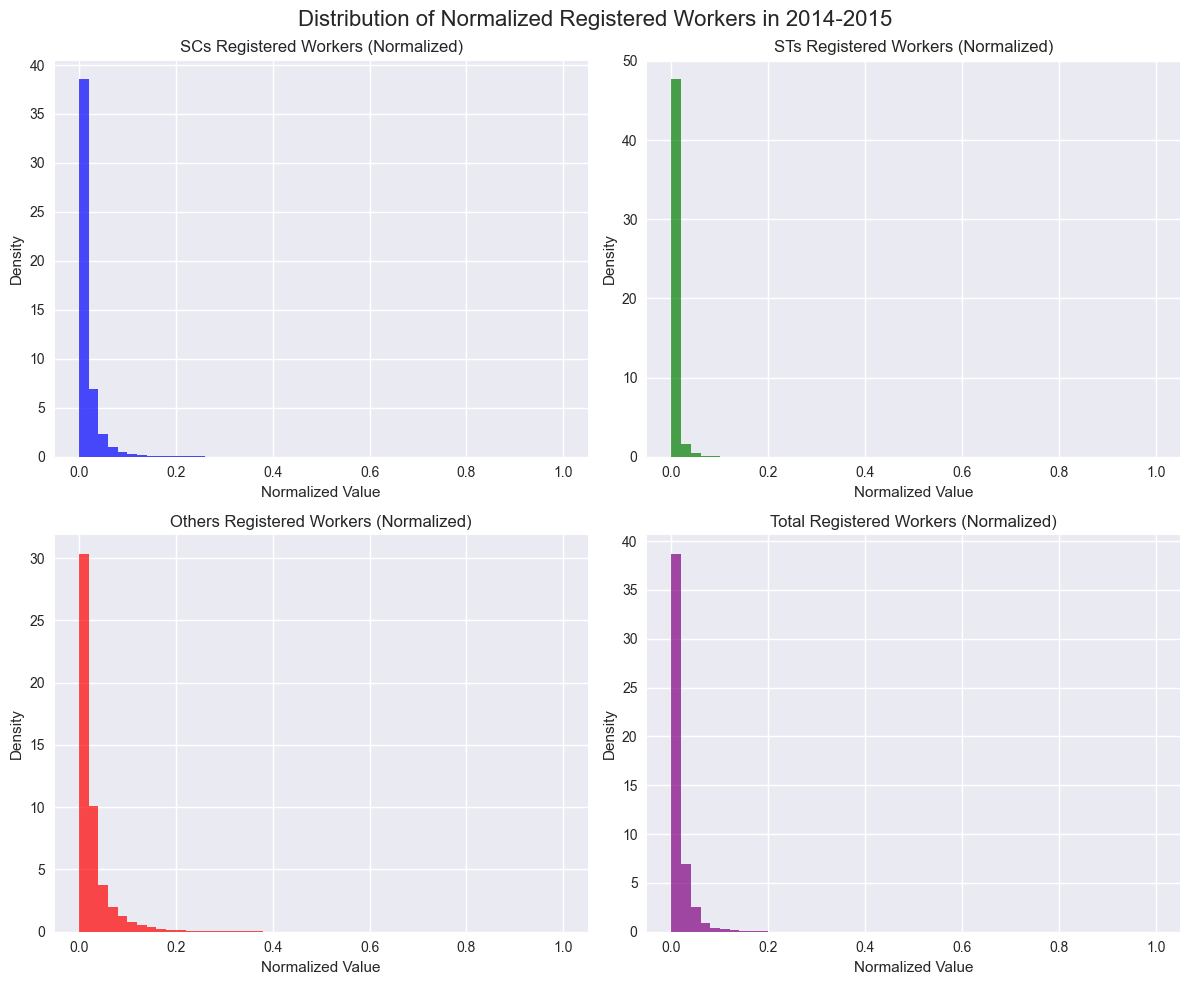

In [25]:
# Normalize the columns using min-max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
columns_to_normalize = ['registered_workers_scs', 'registered_workers_sts', 'registered_workers_others', 'total_registered_workers']
Workers_2014_norm = Workers_2014[columns_to_normalize].copy()
Workers_2014_norm[columns_to_normalize] = scaler.fit_transform(Workers_2014_norm[columns_to_normalize])

# Plot distributions for normalized registered workers
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Normalized Registered Workers in 2014-2015', fontsize=16)

# SCs
axes[0,0].hist(Workers_2014_norm['registered_workers_scs'].dropna(), bins=50, alpha=0.7, color='blue', density=True)
axes[0,0].set_title('SCs Registered Workers (Normalized)')
axes[0,0].set_xlabel('Normalized Value')
axes[0,0].set_ylabel('Density')

# STs
axes[0,1].hist(Workers_2014_norm['registered_workers_sts'].dropna(), bins=50, alpha=0.7, color='green', density=True)
axes[0,1].set_title('STs Registered Workers (Normalized)')
axes[0,1].set_xlabel('Normalized Value')
axes[0,1].set_ylabel('Density')

# Others
axes[1,0].hist(Workers_2014_norm['registered_workers_others'].dropna(), bins=50, alpha=0.7, color='red', density=True)
axes[1,0].set_title('Others Registered Workers (Normalized)')
axes[1,0].set_xlabel('Normalized Value')
axes[1,0].set_ylabel('Density')

# Total
axes[1,1].hist(Workers_2014_norm['total_registered_workers'].dropna(), bins=50, alpha=0.7, color='purple', density=True)
axes[1,1].set_title('Total Registered Workers (Normalized)')
axes[1,1].set_xlabel('Normalized Value')
axes[1,1].set_ylabel('Density')

plt.tight_layout()
plt.show()

/var/folders/_5/7jjn39jx0cqgn7hh4833l9jm0000gn/T/ipykernel_85399/2968335779.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Workers_2014['sc_st_to_others_ratio'] = (Workers_2014['registered_workers_scs'] + Workers_2014['registered_workers_sts']) / Workers_2014['registered_workers_others']


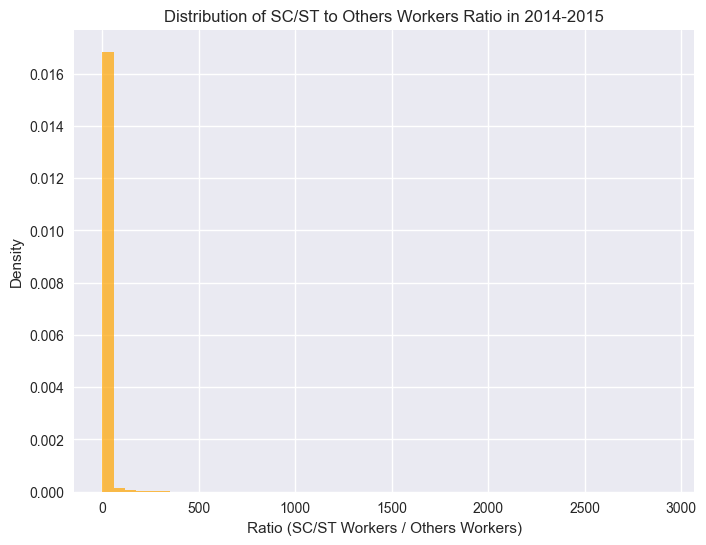

In [26]:
# Create ratio column
Workers_2014['sc_st_to_others_ratio'] = (Workers_2014['registered_workers_scs'] + Workers_2014['registered_workers_sts']) / Workers_2014['registered_workers_others']

# Filter out infinite and NaN values for plotting
ratio_data = Workers_2014['sc_st_to_others_ratio'].replace([np.inf, -np.inf], np.nan).dropna()

# Plot histogram for the ratio
plt.figure(figsize=(8, 6))
plt.hist(ratio_data, bins=50, alpha=0.7, color='orange', density=True)
plt.title('Distribution of SC/ST to Others Workers Ratio in 2014-2015')
plt.xlabel('Ratio (SC/ST Workers / Others Workers)')
plt.ylabel('Density')
plt.show()

In [44]:
mapping = pd.read_csv('/Users/vidhi/college baby/sem 6/Topics in EconRes/FinalPaperMaterial/2. Data/2. Interim/Mittal/V1_panchayat_ID_MIS_index_mapping.csv')
mapping.head()

,Panchayat_ID,Gram_panchayat_name,Subdistrict census code,Subdistrict name,District census code,District name,State census code,State name,mis_index
0,221810,pitchikalapadu,4730,Yetapaka,541,visakhapatnam,28,andhra pradesh,NaN
1,221811,kannaigudem,4730,Yetapaka,541,visakhapatnam,28,andhra pradesh,NaN
2,221812,laxmipuram,4730,Yetapaka,541,visakhapatnam,28,andhra pradesh,NaN
3,221813,ramagopalapuram,4730,Yetapaka,541,visakhapatnam,28,andhra pradesh,NaN
4,221814,nallakunta,4730,Yetapaka,541,visakhapatnam,28,andhra pradesh,NaN


In [55]:
mapping['Panchayat_ID'].astype(float).describe()

ValueError: could not convert string to float: ' 87.20157000241608 25.82768999918297'